In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install catboost

In [4]:
pip install catboost scikit-learn pandas


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training client {i+1} model...")
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='MultiClass',
        verbose=0
    )
    model.fit(client_data[i], client_labels[i])
    client_models.append(model)
    probs += model.predict_proba(X_test)  # Sum probabilities

# ========== Average Probabilities ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluate ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))


Training client 1 model...
Training client 2 model...
Training client 3 model...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.96      0.98      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  56    0    0 1444]]
F1 Score (macro): 0.9878310461628366


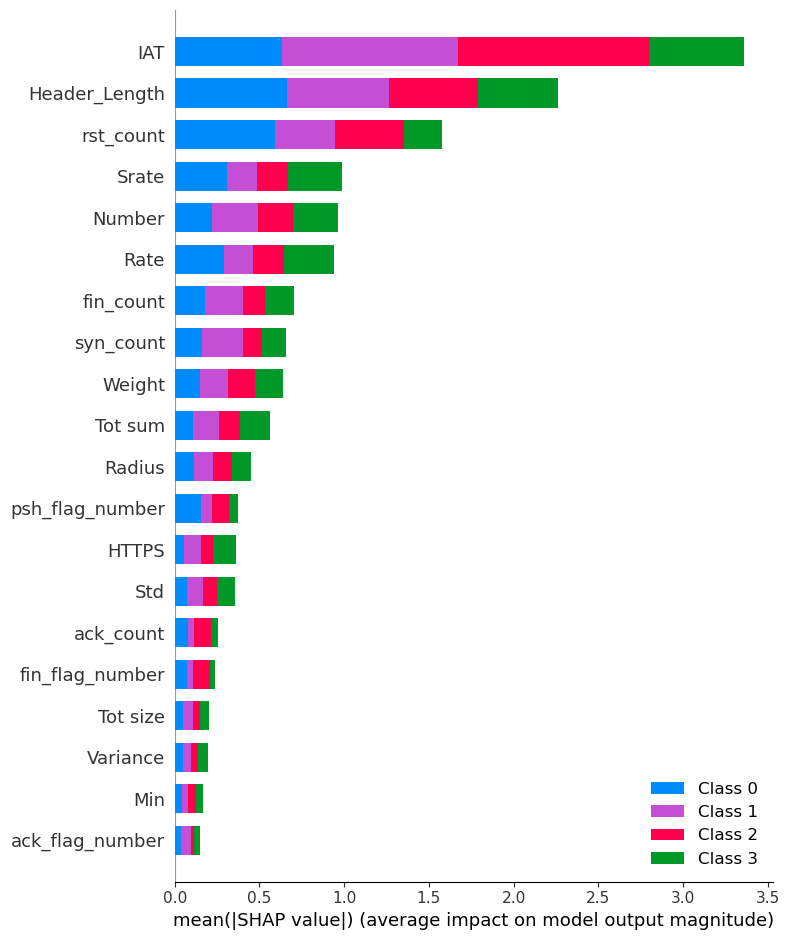

In [10]:
import shap
import matplotlib.pyplot as plt

# Pick one of the trained client models (e.g., client 0)
model = client_models[0]  # or choose client_models[1], etc.

# SHAP requires raw (non-pandas) data
X_sample = X_train.sample(n=300, random_state=42)  # reduce size for speed
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot (multi-class)
shap.summary_plot(shap_values, X_sample, plot_type="bar")


In [15]:
# Redefine all plotting functions

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve, ShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# ========== 1. Learning Curve ==========
def plot_learning_curve(model, X, y, title="Learning Curve"):
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring='f1_macro', train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, label="Train F1", marker='o')
    plt.plot(train_sizes, test_mean, label="Test F1", marker='o')
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score (macro)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ========== 2. Validation Curve ==========
def plot_validation_curve(X, y):
    param_range = [50, 100, 200, 300]
    train_scores, test_scores = validation_curve(
        CatBoostClassifier(loss_function='MultiClass', verbose=0),
        X, y, param_name="iterations", param_range=param_range,
        scoring="f1_macro", cv=3
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(param_range, train_mean, label="Train F1", marker='o')
    plt.plot(param_range, test_mean, label="Test F1", marker='o')
    plt.title("Validation Curve: Iterations vs F1 Score")
    plt.xlabel("Iterations")
    plt.ylabel("F1 Score (macro)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ========== 3. Confusion Matrix ==========
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ========== 4. Histogram of Predictions using ShuffleSplit ==========
def plot_prediction_histogram(model, X, y):
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    predictions = []
    for train_idx, test_idx in cv.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        predictions.extend(preds)
    
    plt.figure(figsize=(7,4))
    plt.hist(predictions, bins=np.arange(len(np.unique(y)) + 1) - 0.5, edgecolor='black')
    plt.title("Histogram of Predicted Labels (ShuffleSplit)")
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.xticks(np.unique(y))
    plt.grid(True)
    plt.show()

# ========== 5. Bar Chart of Class Distributions ==========
def plot_class_distribution(y_true, y_pred):
    df = pd.DataFrame({"True Labels": y_true, "Predicted Labels": y_pred})
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    df['True Labels'].value_counts().sort_index().plot(kind='bar', title='True Class Distribution')
    plt.xlabel("Class")
    plt.ylabel("Count")

    plt.subplot(1,2,2)
    df['Predicted Labels'].value_counts().sort_index().plot(kind='bar', color='orange', title='Predicted Class Distribution')
    plt.xlabel("Class")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# ========== 6. Evaluation Metric Graph ==========
def plot_evaluation_metrics(y_true, y_pred):
    classes = np.unique(y_true)
    precision = precision_score(y_true, y_pred, average=None)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average=None)

    x = np.arange(len(classes))
    width = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - width, precision, width=width, label="Precision")
    plt.bar(x, recall, width=width, label="Recall")
    plt.bar(x + width, f1, width=width, label="F1 Score")
    plt.xticks(x, classes)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title("Evaluation Metrics per Class")
    plt.legend()
    plt.grid(True)
    plt.show()


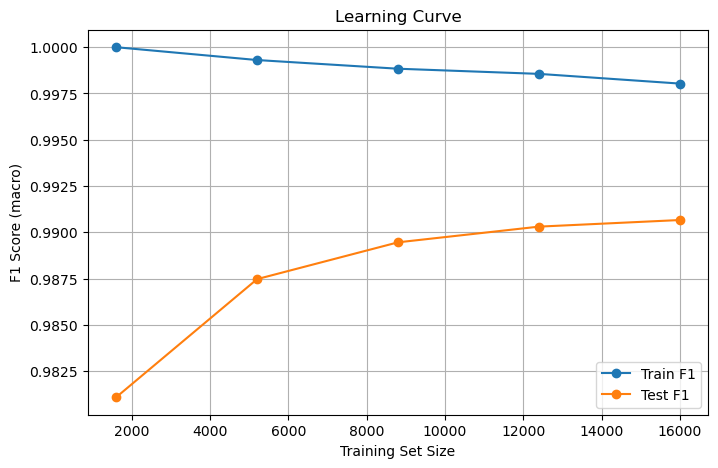

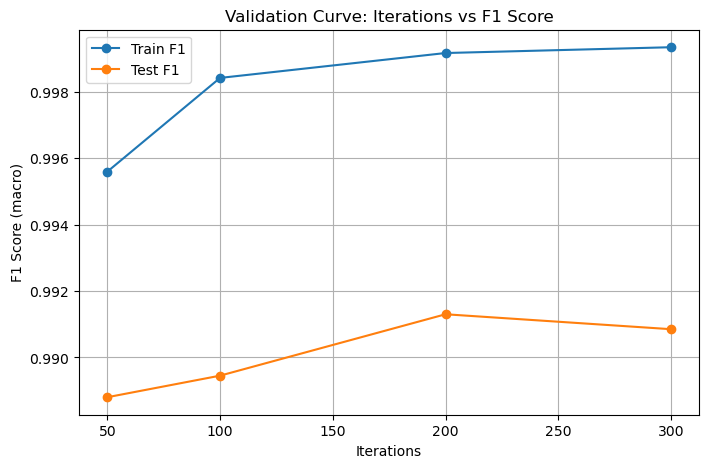

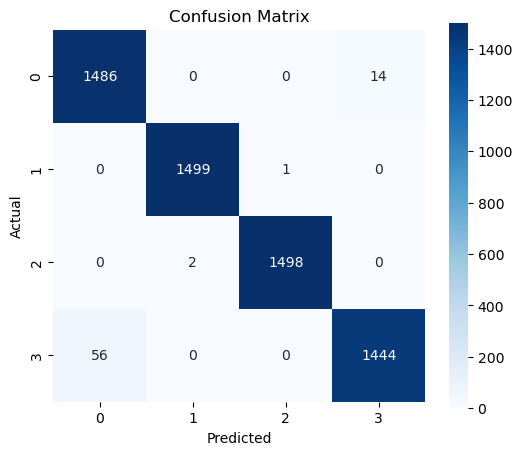

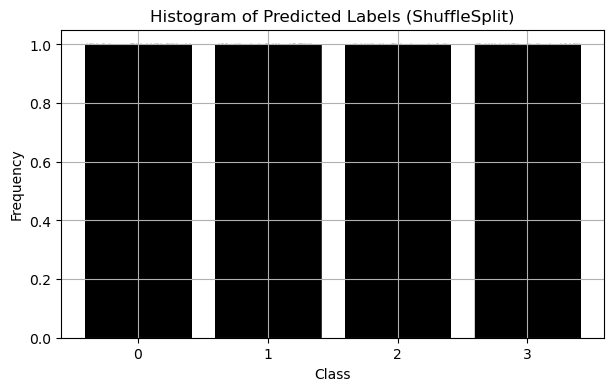

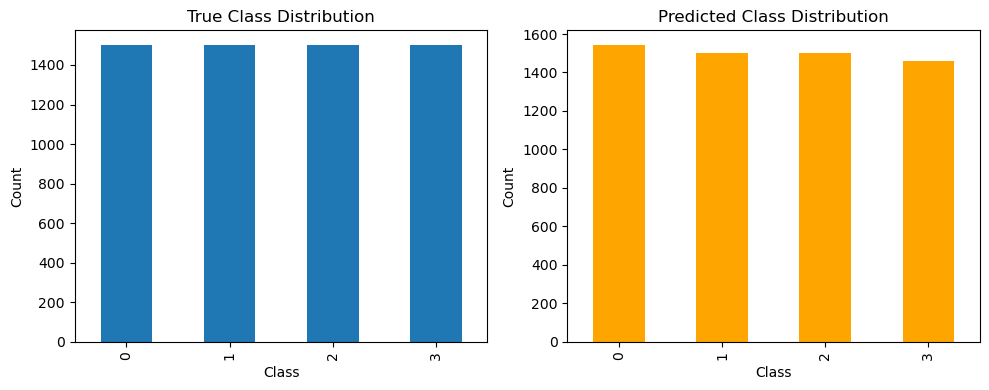

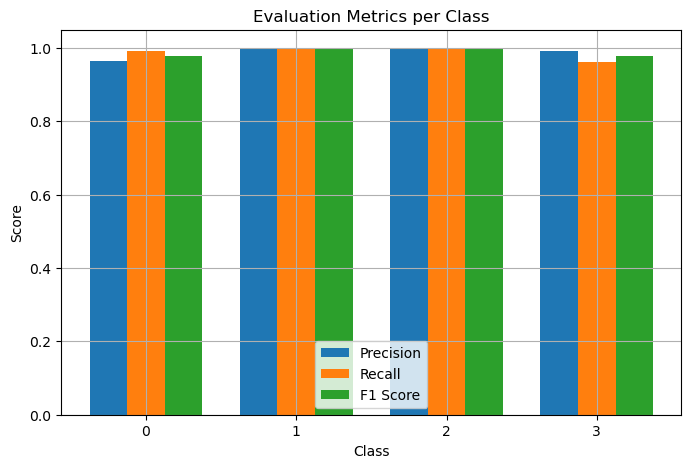

In [17]:
# Create model for plotting (CatBoost compatible with scikit-learn tools)
base_model = CatBoostClassifier(loss_function='MultiClass', iterations=100, verbose=0)

# Run plots
plot_learning_curve(base_model, X_train.values, y_train.values)
plot_validation_curve(X_train, y_train)
plot_confusion_matrix(y_test, y_pred)
plot_prediction_histogram(base_model, X_train, y_train)
plot_class_distribution(y_test, y_pred)
plot_evaluation_metrics(y_test, y_pred)
